## 1 Exploratieve Data Analyse

In deze sectie analyseren we de tabulaire data en de woningafbeeldingen uit de Neural Estate dataset.

**Doel van de EDA:**
- De datastructuur en datakwaliteit valideren.
- Relaties tussen `Price` en features onderzoeken.
- Datagebreken (o.a. outliers en locatieclustering) expliciet vastleggen.
- Modelimplicaties formuleren voor vervolgopdrachten.


### 1.1 Data inladen


In [73]:
# Bestands- en padbeheer
from pathlib import Path

# Reproduceerbare random sampling voor beeldvoorbeelden
import random

# Numerieke en tabulaire analyses
import numpy as np
import pandas as pd

# Visualisaties
import seaborn as sns
import matplotlib.pyplot as plt

# Image I/O voor validatie en sample-weergave
from PIL import Image


In deze cel importeer ik alle libraries die ik later nodig heb voor de analyse, visualisaties en het controleren van afbeeldingen. Door dit als eerste te doen zie je meteen of je omgeving compleet is, voordat we tijd stoppen in het inladen en analyseren van data.


In [74]:
# Consistente visualisatie-instellingen voor de hele notebook
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


Hier zet ik een vaste plotting-stijl en een duidelijke pandas-weergave. Dat maakt grafieken consistent door de hele notebook en voorkomt dat belangrijke kolommen wegvallen in tabellen.


In [75]:
# Data direct inladen vanuit CSV-bestanden
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Basiscontrole op dimensies
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

# Eerste visuele inspectie van trainmetadata
display(train_df.head())


Train shape: (500, 7)
Test shape: (35, 6)


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
0,1,4,4.0,4053,33.6968,-111.8892,869500
1,2,4,3.0,3343,34.8280,-119.0349,865200
2,3,3,4.0,3923,33.7669,-111.9182,889000
3,4,5,5.0,4022,33.7752,-111.7791,910000
4,5,3,4.0,4116,33.7669,-111.9182,971226


Deze cel leest de train- en testmetadata direct uit de CSV-bestanden in. Daarna print ik de shapes en toon ik de eerste rijen, zodat ik meteen kan bevestigen dat de juiste bestanden zijn geladen en dat de kolommen er logisch uitzien.


### 1.2 Datakwaliteit tabulaire data


In [76]:
def quality_report(df: pd.DataFrame) -> dict:
    '''Maak een compact datakwaliteitsrapport voor een DataFrame.'''
    # Verzamel alle kerncontroles in Ã©Ã©n rapportobject
    report = {
        'shape': df.shape,
        'columns': list(df.columns),
        'dtypes': df.dtypes.astype(str).to_dict(),
        'missing_values': df.isna().sum().to_dict(),
        'duplicate_rows': int(df.duplicated().sum()),
        # House ID hoort uniek te zijn. duplicates kunnen label/image-koppeling breken
        'duplicate_house_id': int(df['House ID'].duplicated().sum()) if 'House ID' in df.columns else None,
    }
    return report


def print_quality_report(name: str, report: dict) -> None:
    '''Print het kwaliteitsrapport in een leesbaar formaat.'''
    print(f'\n=== {name} ===')
    print(f"Shape: {report['shape']}")
    print(f"Kolommen: {report['columns']}")
    print('Dtypes:')
    print(pd.Series(report['dtypes']))
    print('Missing values per kolom:')
    print(pd.Series(report['missing_values']))
    print(f"Duplicate rows: {report['duplicate_rows']}")
    print(f"Duplicate House ID: {report['duplicate_house_id']}")


In deze cel definieer ik helperfuncties om snel een kwaliteitsbeeld van een dataset te krijgen, zoals missende waardes en basisstatistieken. Ik doe dit als aparte stap zodat de uitvoercellen straks kort blijven en de checks herhaalbaar zijn voor zowel train als test.


In [77]:
# Kwaliteitsrapporten genereren
train_quality = quality_report(train_df)
test_quality = quality_report(test_df)

# Resultaten overzichtelijk printen
print_quality_report('Train', train_quality)
print_quality_report('Test', test_quality)



=== Train ===
Shape: (500, 7)
Kolommen: ['House ID', 'Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude', 'Price']
Dtypes:
House ID       int64
Bedrooms       int64
Bathrooms    float64
Area           int64
Latitude     float64
Longitude    float64
Price          int64
dtype: object
Missing values per kolom:
House ID     0
Bedrooms     0
Bathrooms    0
Area         0
Latitude     0
Longitude    0
Price        0
dtype: int64
Duplicate rows: 0
Duplicate House ID: 0

=== Test ===
Shape: (35, 6)
Kolommen: ['House ID', 'Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']
Dtypes:
House ID       int64
Bedrooms       int64
Bathrooms    float64
Area           int64
Latitude     float64
Longitude    float64
dtype: object
Missing values per kolom:
House ID     0
Bedrooms     0
Bathrooms    0
Area         0
Latitude     0
Longitude    0
dtype: int64
Duplicate rows: 0
Duplicate House ID: 0


Hier doen we basic EDA op zowel `train_df` als `test_df` en laten we de resultaten overzichtelijk zien.


### 1.3 Target-analyse (`Price`)

We verwijderen outliers nog niet uit de basisdataset.


In [78]:
def target_report(df: pd.DataFrame, target_col: str = 'Price') -> dict:
    '''Analyseer targetverdeling, scheefheid en outliers op target en prijs per sqft.'''
    if target_col not in df.columns:
        raise ValueError(f"Kolom '{target_col}' zit niet in df.")

    # Targetkolom selecteren
    y = df[target_col]

    # IQR-outlierdetectie:
    # IQR = Q3 - Q1
    # Ondergrens = Q1 - 1.5*IQR
    # Bovengrens = Q3 + 1.5*IQR
    q1 = float(y.quantile(0.25))
    q3 = float(y.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (y < lower) | (y > upper)

    report = {
        'describe': y.describe().to_dict(),
        'skew_price': float(y.skew()),
        'iqr_bounds_price': (float(lower), float(upper)),
        'n_outliers_price': int(outlier_mask.sum()),
        'outlier_house_ids': df.loc[outlier_mask, 'House ID'].tolist() if 'House ID' in df.columns else [],
    }

    # Extra outlieranalyse op prijs per sqft voor detectie van onrealistische waarderingen
    if 'Area' in df.columns:
        ppsf = y / df['Area']
        pq1, pq3 = ppsf.quantile([0.25, 0.75])
        piqr = pq3 - pq1
        plower, pupper = pq1 - 1.5 * piqr, pq3 + 1.5 * piqr
        p_outlier_mask = (ppsf < plower) | (ppsf > pupper)

        report['price_per_sqft_describe'] = ppsf.describe().to_dict()
        report['iqr_bounds_price_per_sqft'] = (float(plower), float(pupper))
        report['n_outliers_price_per_sqft'] = int(p_outlier_mask.sum())
        report['ppsf_outlier_house_ids'] = df.loc[p_outlier_mask, 'House ID'].tolist() if 'House ID' in df.columns else []

    return report


def plot_target_analysis(df: pd.DataFrame, target_col: str = 'Price') -> None:
    '''Toon target-distributies: raw, zoomed'''
    y = df[target_col]

    # Zelfde IQR-bovengrens gebruiken voor een leesbare zoomed plot
    q1, q3 = y.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # Raw distributie
    sns.histplot(y, bins=35, kde=True, ax=axes[0, 0], color='#1f77b4')
    axes[0, 0].set_title('Price distributie (raw)')
    axes[0, 0].set_xlabel('Price (USD)')

    # Raw boxplot voor snelle outlierdetectie
    sns.boxplot(x=y, ax=axes[0, 1], color='#ff7f0e')
    axes[0, 1].set_title('Price boxplot (raw)')
    axes[0, 1].set_xlabel('Price (USD)')

    # Zoomed distributie (outliers alleen verborgen in plot, niet verwijderd uit dataset)
    sns.histplot(y[y <= upper], bins=35, kde=True, ax=axes[1, 0], color='#2ca02c')
    axes[1, 0].set_title('Price distributie (zoomed, top-outliers gefilterd in plot)')
    axes[1, 0].set_xlabel('Price (USD)')

    plt.tight_layout()
    plt.show()


Deze cel bevat functies die specifiek de target `Price` analyseren, bijvoorbeeld verdeling en basiskenmerken. Het doel is om target patronen te begrijpen, zodat we betere keuzes kunnen maken voor preprocessing en model aanpak.


Target report (samenvatting):
Skew Price: 3.613
Price outliers (IQR): 23
Price per sqft outliers (IQR): 24
Price IQR bounds: (-536000.0, 1520000.0)


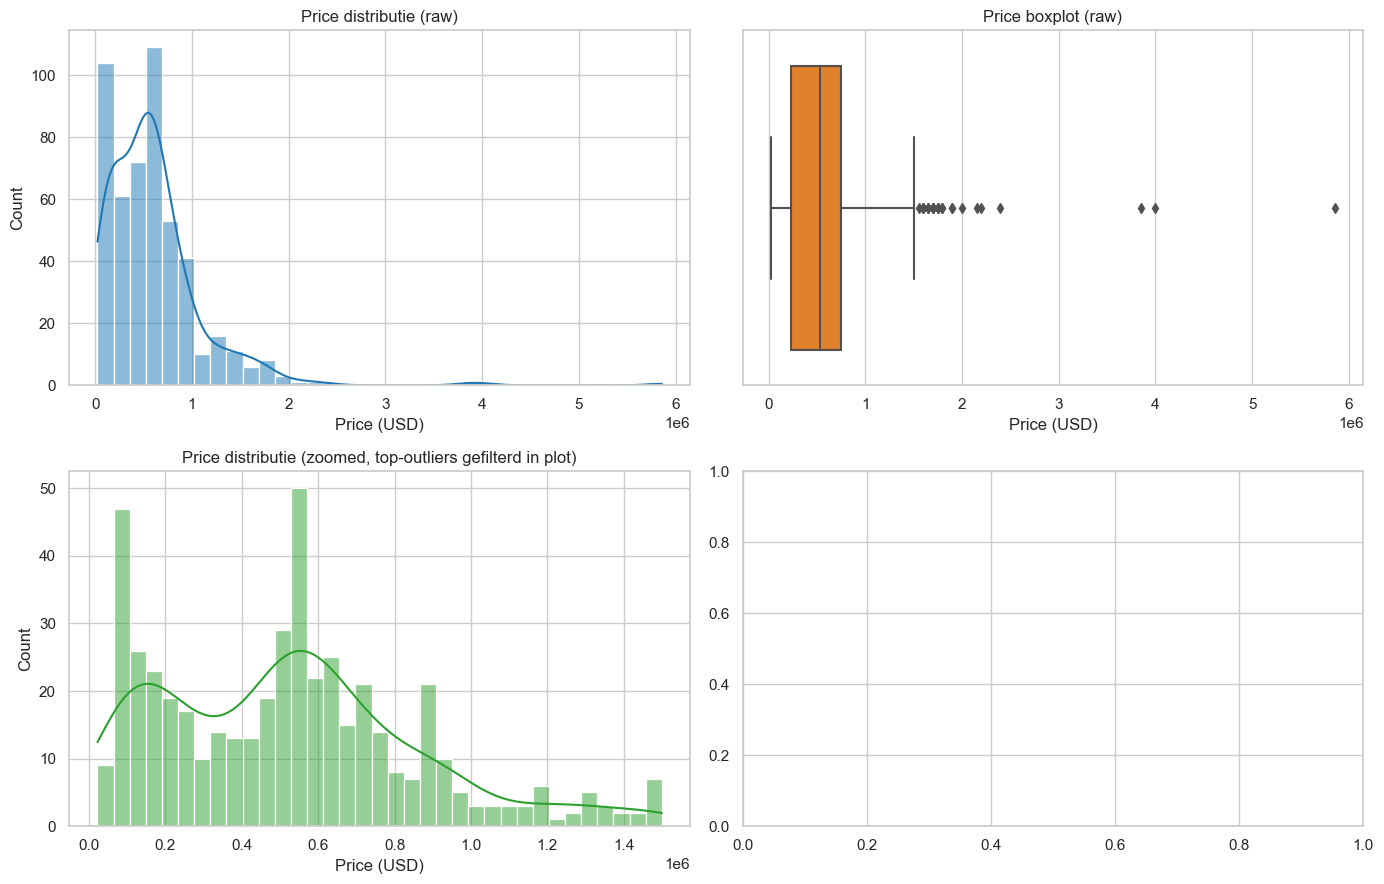

In [79]:
# Targetrapport opbouwen
target_stats = target_report(train_df)

# Kerncijfers printen voor snelle rapportage in tekst
print('Target report (samenvatting):')
print(f"Skew Price: {target_stats['skew_price']:.3f}")
print(f"Price outliers (IQR): {target_stats['n_outliers_price']}")
print(f"Price per sqft outliers (IQR): {target_stats.get('n_outliers_price_per_sqft', 'n.v.t.')}")
print(f"Price IQR bounds: {target_stats['iqr_bounds_price']}")

# Visualisaties genereren
plot_target_analysis(train_df)


Hier voeren we de target-analyse uit op `train_df` en maken we de bijbehorende visualisaties. Dit helpt om snel te zien of `Price` scheef verdeeld is, extreme waarden bevat, of een transformatie zinvol kan zijn.


### 1.4 Relaties tussen features en target


In [80]:
def feature_target_plots(df: pd.DataFrame, target_col: str = 'Price') -> pd.Series:
    '''Visualiseer feature-target relaties (raw + zoomed) en correlaties.'''
    features = ['Area', 'Bathrooms', 'Bedrooms']

    # Consistente IQR-bovengrens voor zoomed weergaves
    q1, q3 = df[target_col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    zoom_df = df[df[target_col] <= upper].copy()

    # Bovenste rij: raw, onderste rij: zoomed
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for idx, feature in enumerate(features):
        sns.scatterplot(data=df, x=feature, y=target_col, alpha=0.6, ax=axes[0, idx], color='#1f77b4')
        axes[0, idx].set_title(f'{feature} vs {target_col} (raw)')

        sns.scatterplot(data=zoom_df, x=feature, y=target_col, alpha=0.6, ax=axes[1, idx], color='#2ca02c')
        axes[1, idx].set_title(f'{feature} vs {target_col} (zoomed)')

    plt.tight_layout()
    plt.show()

    # Correlatiematrix over alle numerieke kolommen
    numeric_cols = df.select_dtypes(include=np.number).columns
    corr_matrix = df[numeric_cols].corr(numeric_only=True)

    # Heatmap toont lineaire samenhang, geen causaliteit
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlatie-heatmap (numerieke kolommen)')
    plt.tight_layout()
    plt.show()

    # Return gesorteerde correlaties met target voor tekstsamenvatting
    corr_with_target = corr_matrix[target_col].sort_values(ascending=False)
    return corr_with_target


In deze cel definieren we functies om relaties tussen features en `Price` te verkennen met plots en eenvoudige correlaties. Zo kunnen e later dezelfde code gebruiken zonder telkens dezelfde plotting code te herhalen.


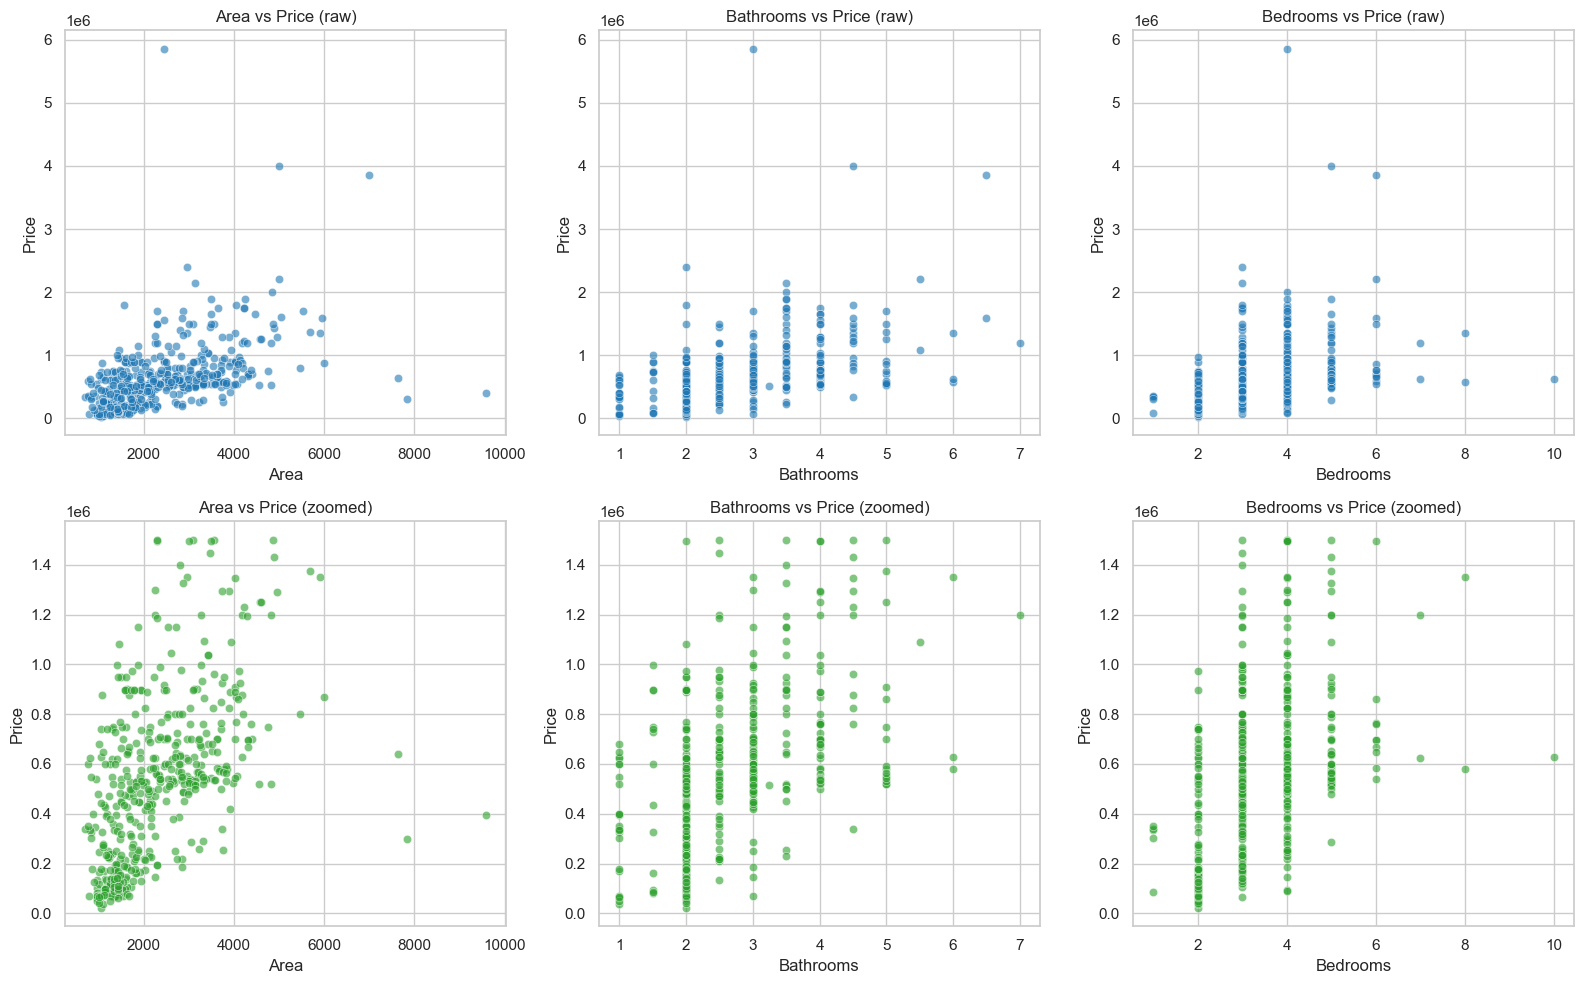

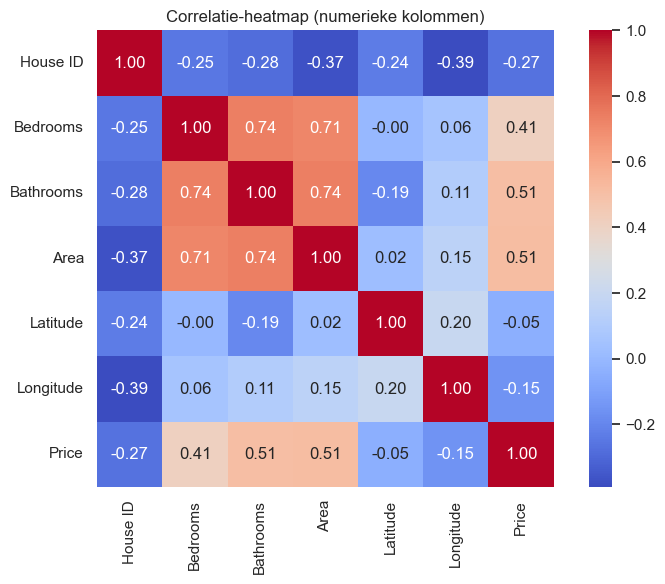

Correlatie met Price:
Price        1.000000
Area         0.512733
Bathrooms    0.507602
Bedrooms     0.413018
Latitude    -0.047535
Longitude   -0.154991
House ID    -0.270197
Name: Price, dtype: float64


In [81]:
# Analyse uitvoeren en correlaties met Price ophalen
corr_with_price = feature_target_plots(train_df)

# Gesorteerde correlaties printen voor directe rapportage
print('Correlatie met Price:')
print(corr_with_price)


Deze cel draait de feature target analyse op de trainingsdata en geeft een eerste indicatie welke features mogelijk informatief zijn


### 1.5 Geografische patronen


In [82]:
def geo_analysis(df: pd.DataFrame) -> dict:
    '''Analyseer locatieclustering en prijsvariatie per geolocatie.'''
    # Frequentie per unieke (Latitude, Longitude)-combinatie
    geo_counts = df.groupby(['Latitude', 'Longitude']).size().sort_values(ascending=False)
    unique_geo = int(geo_counts.shape[0])

    # Prijsstatistiek voor de meest voorkomende locaties
    spread = (
        df.groupby(['Latitude', 'Longitude'])['Price']
        .agg(['count', 'median', 'min', 'max'])
        .sort_values('count', ascending=False)
        .head(10)
    )

    # Geografische spreiding visualiseren; kleur representeert prijsniveau
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        df['Longitude'],
        df['Latitude'],
        c=df['Price'],
        cmap='viridis',
        alpha=0.75,
        s=40,
        edgecolor='k',
        linewidth=0.2,
    )
    plt.colorbar(scatter, label='Price (USD)')
    plt.title('Geografische spreiding van woningen (kleur = Price)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

    report = {
        'unique_geolocations': unique_geo,
        'total_rows': int(len(df)),
        'top_geo_counts': geo_counts.head(10),
        'top_geo_price_spread': spread,
    }
    return report


Hier definieren we functies om geografische patronen in de data te analyseren, bijvoorbeeld clustering of verschillen per locatie. Locatie is vaak een sterke driver voor prijs en kan ook voor outliers zorgen.


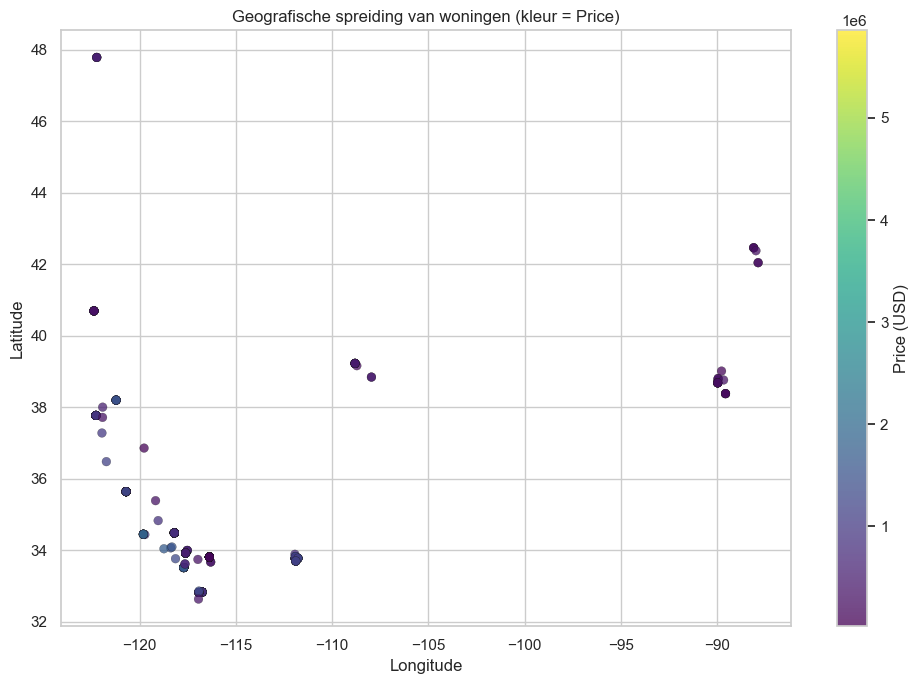

Unieke geolocaties: 47 op 500 rijen
Top geolocaties op frequentie:
Latitude  Longitude
33.8082   -116.3713    100
34.4835   -118.1959     60
35.6406   -120.7003     50
33.9208   -117.6096     49
37.7706   -122.2648     41
32.8282   -116.7543     32
33.5145   -117.7084     26
33.6968   -111.8892     12
40.6969   -122.3683     12
34.4453   -119.8025     11
dtype: int64
Prijs-range voor top geolocaties:
                    count     median     min      max
Latitude Longitude                                   
33.8082  -116.3713    100   105475.0   36000   385000
34.4835  -118.1959     60   549475.0  195000  5858000
35.6406  -120.7003     50   504750.0  125000  2395000
33.9208  -117.6096     49   539800.0  448000   749000
37.7706  -122.2648     41   749000.0  339000  1895000
32.8282  -116.7543     32   684000.0   65000  1499000
33.5145  -117.7084     26   882000.0  324999  3850000
33.6968  -111.8892     12  1039000.0  500000  1749000
40.6969  -122.3683     12   239900.0   22000  1795000
34

In [83]:
# Geo-analyse uitvoeren
geo_report = geo_analysis(train_df)

# Kernuitkomsten printen
print(f"Unieke geolocaties: {geo_report['unique_geolocations']} op {geo_report['total_rows']} rijen")
print('Top geolocaties op frequentie:')
print(geo_report['top_geo_counts'])
print('Prijs-range voor top geolocaties:')
print(geo_report['top_geo_price_spread'])


In deze cel voeren we de geo-analyse uit op `train_df` en toon ik de belangrijkste bevindingen. Het doel is om te begrijpen of locatie variabelen speciale behandeling nodig hebben en of er ruimtelijke patronen zijn die het model kan benutten.


### 1.6 Beelddata-validatie en sample-visualisatie


In [84]:
def validate_image_folder(folder_path: Path, expected_count: int) -> dict:
    '''Controleer aantal beelden, formaat, modus en corrupte bestanden.'''
    files = sorted(folder_path.glob('*.jpg'))
    sizes = []
    modes = []
    corrupted = []

    # Loop over alle beelden en verzamel technische metadata
    for fp in files:
        try:
            with Image.open(fp) as im:
                sizes.append(im.size)
                modes.append(im.mode)
        except Exception:
            # Als openen faalt, markeren als corrupt bestand
            corrupted.append(fp.name)

    report = {
        'folder': str(folder_path),
        'expected_count': expected_count,
        'actual_count': len(files),
        'count_match': len(files) == expected_count,
        'unique_sizes': sorted(set(sizes)),
        'unique_modes': sorted(set(modes)),
        'corrupted_files': corrupted,
    }
    return report


def compare_csv_image_ids(df: pd.DataFrame, folder_path: Path) -> dict:
    '''Controleer of House ID waarden in CSV overeenkomen met image bestandsnamen.'''
    # IDs uit metadata
    csv_ids = set(df['House ID'].astype(int).tolist())
    # IDs uit bestandsnamen (bijv. 123.jpg -> 123)
    image_ids = {int(fp.stem) for fp in folder_path.glob('*.jpg') if fp.stem.isdigit()}

    # Vergelijking in beide richtingen om ontbrekende koppelingen te vinden
    return {
        'csv_minus_images': sorted(csv_ids - image_ids),
        'images_minus_csv': sorted(image_ids - csv_ids),
    }


def show_image_samples(folder_path: Path, n: int = 8, seed: int = 42) -> None:
    '''Toon representatieve random samples uit een map met woningafbeeldingen.'''
    image_paths = sorted(folder_path.glob('*.jpg'))

    # Bescherm tegen n groter dan aantal beschikbare afbeeldingen
    if n > len(image_paths):
        n = len(image_paths)

    # Vaste seed voor reproduceerbare selectie
    rng = random.Random(seed)
    sample_paths = rng.sample(image_paths, n)

    # Rasterinstellingen voor plotweergave
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)

    # Aslijnen uitzetten zodat alleen beelden zichtbaar zijn
    for ax in axes:
        ax.axis('off')

    # Geselecteerde afbeeldingen tonen
    for ax, fp in zip(axes, sample_paths):
        with Image.open(fp) as im:
            ax.imshow(im)
            ax.set_title(f'House ID: {fp.stem}')
            ax.axis('off')

    plt.suptitle('Representatieve samples uit Train', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


Deze cel definieert functies om te controleren of de image mappen kloppen met de CSV's, en om later snel voorbeelden te kunnen tonen. Ook hier scheiden dit van de rest zodat validatie en visualisatie herhaalbaar blijven


Train image report: {'folder': 'Train', 'expected_count': 500, 'actual_count': 500, 'count_match': True, 'unique_sizes': [(1024, 1024)], 'unique_modes': ['RGB'], 'corrupted_files': []}
Test image report: {'folder': 'Test', 'expected_count': 35, 'actual_count': 35, 'count_match': True, 'unique_sizes': [(1024, 1024)], 'unique_modes': ['RGB'], 'corrupted_files': []}
Train CSV/Image ID check: {'csv_minus_images': [], 'images_minus_csv': []}
Test CSV/Image ID check: {'csv_minus_images': [], 'images_minus_csv': []}


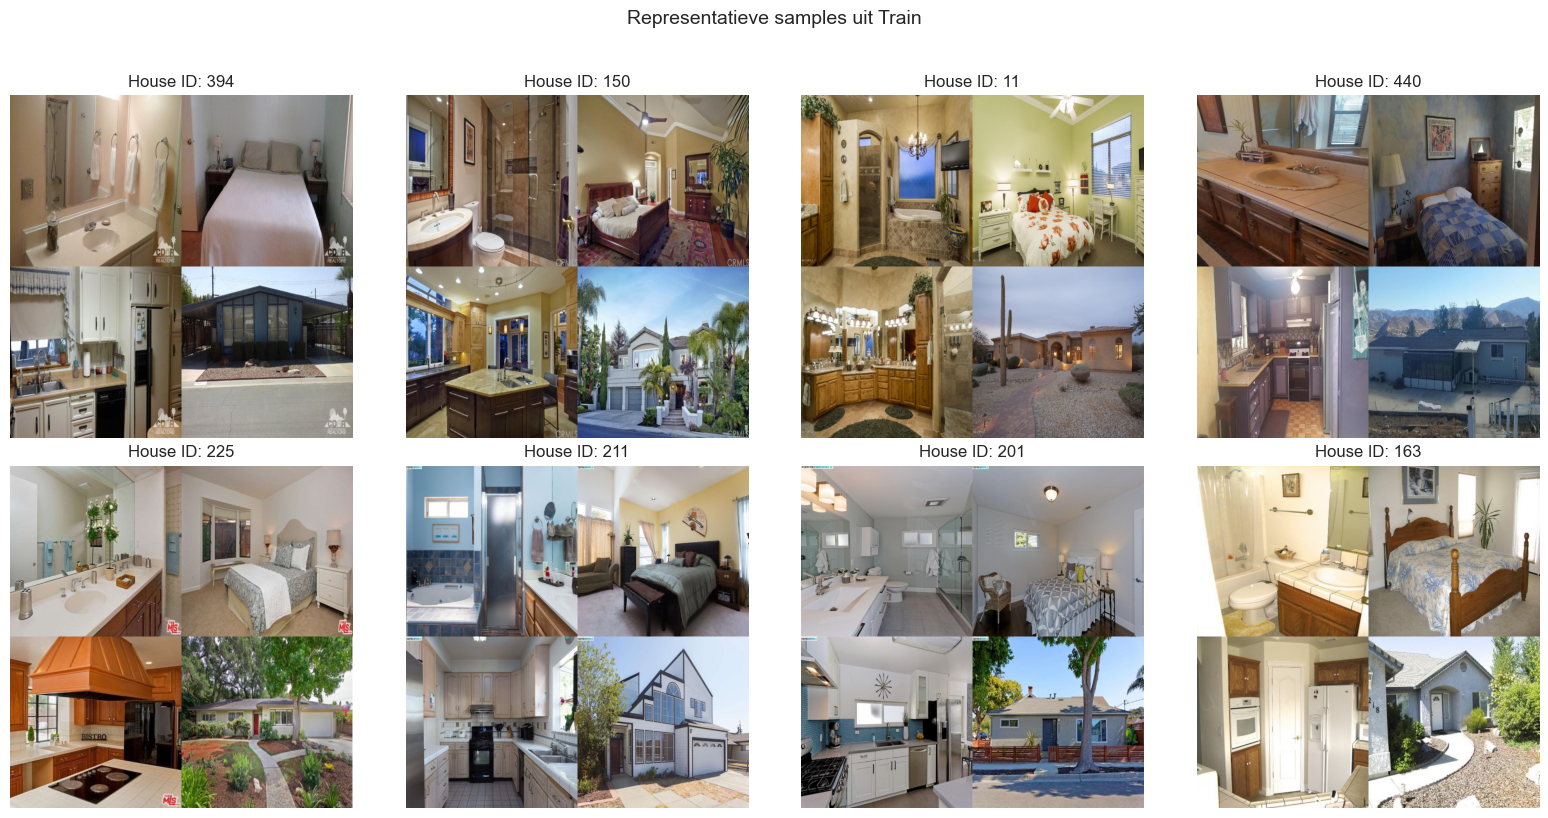

In [85]:
# Technische validatie van train- en testbeeldmappen
train_img_report = validate_image_folder(Path('Train'), expected_count=len(train_df))
test_img_report = validate_image_folder(Path('Test'), expected_count=len(test_df))

# Controle of CSV-ID's en image-ID's exact overeenkomen
train_id_check = compare_csv_image_ids(train_df, Path('Train'))
test_id_check = compare_csv_image_ids(test_df, Path('Test'))

# Resultaten printen voor rapportage
print('Train image report:', train_img_report)
print('Test image report:', test_img_report)
print('Train CSV/Image ID check:', train_id_check)
print('Test CSV/Image ID check:', test_id_check)

# Visuele kwaliteitscheck met reproduceerbare samplebeelden
show_image_samples(Path('Train'), n=8, seed=42)


Hier valideren we de train en testbeeldmappen tegen de metadata en laat ik een paar voorbeeldafbeeldingen zien. We willen zeker weten dat IDs matchen en dat de beelden leesbaar zijn voordat we  een CV model gaan trainen.


### 1.7 Belangrijkste bevindingen en implicaties

**Belangrijkste EDA-bevindingen**
- De metadata is schoon: geen missende waarden, geen duplicate rows en geen duplicate `House ID`.
- Beelddata is consistent: aantallen kloppen met CSV, geen corrupte afbeeldingen, uniform formaat (`1024x1024`, RGB).
- `Price` is sterk rechts-scheef verdeeld.
- Sterkste lineaire verbanden met `Price` zitten in `Area`, `Bathrooms` en `Bedrooms`.
- Er zijn duidelijke prijs en prijs per vierkante voet outliers. Deze zijn **niet verwijderd**.
- Locatiegegevens zijn sterk geclusterd (relatief weinig unieke coordinaten t.o.v. aantal woningen), met grote prijsvariatie binnen dezelfde locatie.
- `House ID` correleert met `Price`, maar is een identifier en wordt in modellering niet als feature gebruikt.


# 2 Fully-connected neuraal netwerk

### 2.1 Fully connected netwerk bouwen
In deze deelopdracht bouwen we een fully-connected neuraal netwerk om huizenprijzen te voorspellen op basis van uitsluitend de tabulaire metadata. We gebruiken de volgende invoervariabelen:
	•	Bedrooms
	•	Bathrooms
	•	Area
	•	Latitude
	•	Longitude

De kolom House ID wordt niet meegenomen, omdat dit alleen een identifier is en geen inhoudelijke eigenschap van een woning.

Uit de EDA bleek dat Price sterk rechts-scheef verdeeld is en outliers bevat. Daarom gebruiken we:
	•	log1p(Price) als targettransformatie
	•	Huber loss als lossfunctie
	•	feature scaling met StandardScaler

### 2.2 Reproduceerbaarheid

In [86]:
np.random.seed(42)
torch.manual_seed(42)

### 2.3 Data voorbereiden

In [87]:
# Features en target
feature_cols = ['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']
target_col = 'Price'

X = train_df[feature_cols].copy()
y = train_df[target_col].copy()

# Log-transformatie van target omdat rechts-scheve verdeling
y_log = np.log1p(y)
2

2

### 2.4 Train/validatie split en scaling

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### 2.5 Omzetten naar PyTorch tensors

In [89]:
import torch
from torch.utils.data import DataLoader, TensorDataset

#tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.reshape(-1, 1), dtype=torch.float32)

#dataloaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)

### 2.6 Model maken

- Aantal lagen en neuronen: 

We hebben gekozen voor drie verborgen lagen met respectievelijk 64, 32 en 16 neuronen. Deze opbouw is groot genoeg om niet-lineaire patronen in de data te leren, maar ook compact genoeg om overfitting te beperken. Dat is belangrijk, omdat de trainingsset uit slechts 500 woningen bestaat.

- Activeringsfuncties
Voor de verborgen lagen is gekozen voor ReLU. Deze functie is efficiënt en werkt in de praktijk goed bij neurale netwerken. Voor de outputlaag is geen activatiefunctie gebruikt, omdat het model één continue numerieke waarde, de woningprijs. moet voorspellen.



In [90]:
import torch.nn as nn

class HousePriceNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = HousePriceNN()
print(model)

HousePriceNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)


### 2.6 Loss en optimizer
Voor dit probleem kiezen we: Lossfunctie: HuberLoss Optimizer: Adam

**loss functie:**
De meest geschikte lossfunctie voor dit probleem is Huber loss. Tijdens de EDA bleek dat de targetvariabele Price rechts-scheef verdeeld is en outliers bevat. Huber loss is dan geschikter dan MSE, omdat grote fouten minder extreem zwaar worden bestraft.

**Optimizer:**
De gekozen optimizer is Adam. Adam is een uitbreiding op gradient descent die gebruikmaakt van eerdere gradiënten en adaptieve learning rates per parameter. Daardoor convergeert training vaak sneller en stabieler.

In [91]:
criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### 2.7 Training van model
Er is gekozen voor maximaal 200 epochs. Tegelijkertijd wordt early stopping gebruikt, zodat de training automatisch stopt zodra de validatieloss langere tijd niet meer verbetert. Dit vermindert de kans op overfitting.

In [92]:
epochs = 200
patience = 20

best_val_loss = float('inf')
counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    #trainen
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    #validatie
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    #early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping!")
        break

model.load_state_dict(best_weights)

Epoch 1: train=12.4874, val=12.3158
Epoch 2: train=12.2246, val=11.9268
Epoch 3: train=11.7080, val=11.1025
Epoch 4: train=10.5954, val=9.4231
Epoch 5: train=8.3925, val=6.2721
Epoch 6: train=5.0351, val=3.2255
Epoch 7: train=3.4476, val=3.4844
Epoch 8: train=3.0603, val=2.7969
Epoch 9: train=2.6616, val=2.2392
Epoch 10: train=2.3487, val=1.9467
Epoch 11: train=2.2234, val=1.7019
Epoch 12: train=1.9468, val=1.4605
Epoch 13: train=1.7439, val=1.2753
Epoch 14: train=1.7136, val=1.1462
Epoch 15: train=1.5494, val=1.0389
Epoch 16: train=1.4738, val=0.9541
Epoch 17: train=1.3724, val=0.8755
Epoch 18: train=1.2919, val=0.7381
Epoch 19: train=1.2465, val=0.6282
Epoch 20: train=1.1715, val=0.5660
Epoch 21: train=1.0755, val=0.5639
Epoch 22: train=1.1832, val=0.4805
Epoch 23: train=1.0677, val=0.4667
Epoch 24: train=1.1511, val=0.5700
Epoch 25: train=1.1268, val=0.3910
Epoch 26: train=1.0353, val=0.3798
Epoch 27: train=1.0991, val=0.3279
Epoch 28: train=0.9145, val=0.2902
Epoch 29: train=1.0029

<All keys matched successfully>

### 2.8 Trainingsverloop plotten

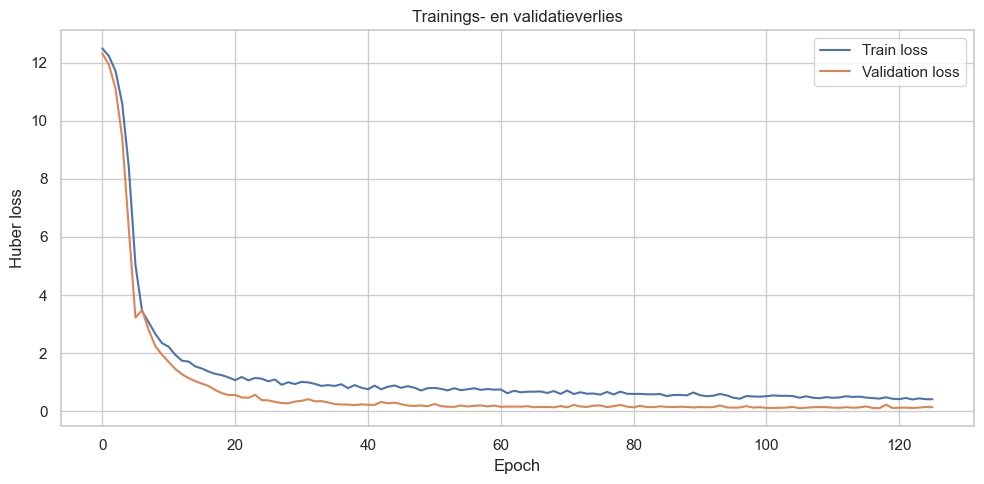

In [93]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.title('Trainings- en validatieverlies')
plt.xlabel('Epoch')
plt.ylabel('Huber loss')
plt.legend()
plt.tight_layout()
plt.show()

### 2.9 Evaluatie op validatieset
Omdat het model voorspelt op log1p(Price), zetten we de voorspellingen weer terug naar de originele prijsschaal met np.expm1().

In [ ]:
model.eval()

with torch.no_grad():
    y_pred_log = model(X_val_tensor).numpy().flatten()

# terugtransformeren
y_true = np.expm1(y_val)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2: {r2:.4f}")

MAE: 981,972.26
RMSE: 7,739,213.87
R2: -320.2737


### 2.10 Werkelijke vs voorspelde prijzen

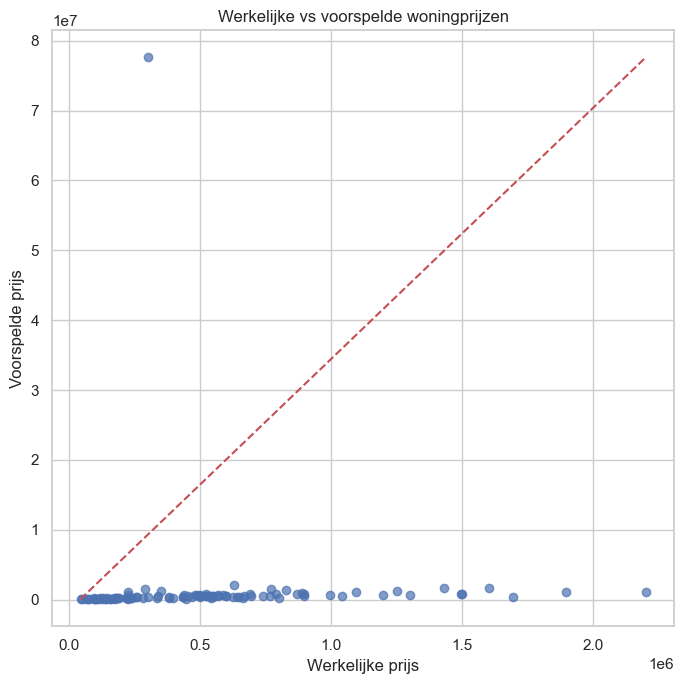

In [97]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot(
    [y_true.min(), y_true.max()],
    [y_pred.min(), y_pred.max()],
    'r--'
)
plt.xlabel('Werkelijke prijs')
plt.ylabel('Voorspelde prijs')
plt.title('Werkelijke vs voorspelde woningprijzen')
plt.tight_layout()
plt.show()

### 2.11 Voorspellingen maken voor de testset

In [ ]:
#Testdata voorbereiden
X_test = test_df[feature_cols].copy()
X_test_scaled = scaler.transform(X_test)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

#Voorspellen
model.eval()
with torch.no_grad():
    test_pred_log = model(X_test_tensor).numpy().flatten()

test_pred_price = np.expm1(test_pred_log)

submission_df = pd.DataFrame({
    'House ID': test_df['House ID'],
    'Price': test_pred_price
})

display(submission_df.head())

#opslaan
submission_df.to_csv('submission_pytorch_nn.csv', index=False)
print("Bestand opgeslagen als submission_pytorch_nn.csv")

,House ID,Price
0,501,728496.31250
1,502,381453.03125
2,503,398312.53125
3,504,798787.00000
4,505,456460.46875


Bestand opgeslagen als submission_pytorch_nn.csv


### 2.12 Architectuur plot

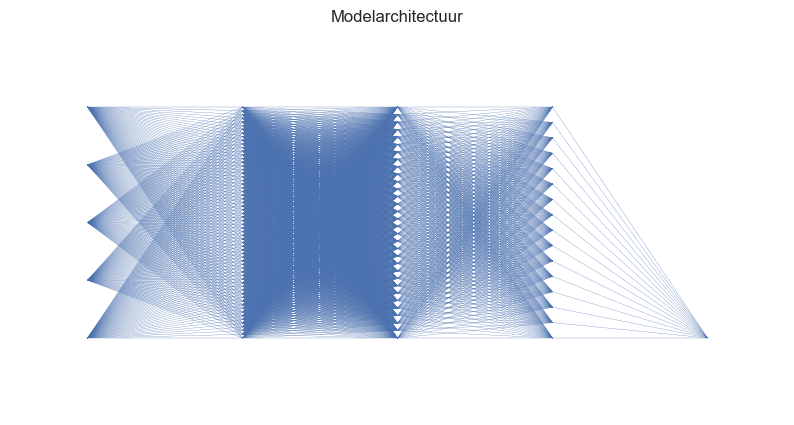

In [95]:
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

def plot_network():
    layer_sizes = [5, 64, 32, 16, 1]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis('off')

    x_positions = np.linspace(0.1, 0.9, len(layer_sizes))

    for i, (x, size) in enumerate(zip(x_positions, layer_sizes)):
        y_positions = np.linspace(0.2, 0.8, size)

        for y in y_positions:
            ax.add_patch(Circle((x, y), 0.015, fill=False))

        if i < len(layer_sizes)-1:
            next_y = np.linspace(0.2, 0.8, layer_sizes[i+1])
            for y1 in y_positions:
                for y2 in next_y:
                    ax.add_line(Line2D([x, x_positions[i+1]], [y1, y2], lw=0.2))

    plt.title("Modelarchitectuur")
    plt.show()

plot_network()

### 2.13 conclusie
Voor deze deelopdracht is een fully-connected neuraal netwerk gebouwd op basis van uitsluitend de tabulaire metadata. Het model gebruikt de variabelen Bedrooms, Bathrooms, Area, Latitude en Longitude om woningprijzen te voorspellen. Omdat de prijsverdeling scheef is en outliers bevat, is gewerkt met een log-transformatie van de target en met Huber loss. In combinatie met een compact netwerk, ReLU-activaties, de Adam optimizer en early stopping ontstaat een passend model voor deze dataset.

## Bronnen

https://chatgpt.com/share/69a9c6c9-84d4-8012-b274-10127ef4d4d0